# TripPocket · Аналитика кошелька

Работает на JSON-экспорте из приложения (бэкап v2): **Настройки → Экспорт данных (JSON)**.
По умолчанию берёт `trippocket-import.json` из корня проекта (история эксельки) —
для живых данных положи свежий экспорт рядом и поправь путь в первой ячейке.

Запуск: `jupyter lab scripts/analytics.ipynb` → Run All.

In [1]:
import json
from pathlib import Path

import pandas as pd

# ── путь к выгрузке ──────────────────────────────────────────────────────
CANDIDATES = [
    Path("../trippocket-import.json"),   # запуск из scripts/
    Path("trippocket-import.json"),      # запуск из корня проекта
]
BACKUP = next((p for p in CANDIDATES if p.exists()), None)
assert BACKUP, "Не найден JSON-экспорт: положи файл рядом или поправь путь"

raw = json.loads(BACKUP.read_text())
assert raw.get("version") == 2, "Ожидается бэкап v2 (приложение сборки 10+)"

HOME = raw.get("homeCurrency", "RUB")
cats = {c["id"]: c["name"] for c in raw["categories"]}
sphere_names = {s["id"]: s["name"] for s in raw["spheres"]}
sphere_order = [s["id"] for s in sorted(raw["spheres"], key=lambda s: s["sort_order"])]
sphere_meta = {s["id"]: s for s in raw["spheres"]}

df = pd.DataFrame(raw["transactions"])
same_cur = df["currency"] == HOME
df["value"] = df["amount_home"].where(df["amount_home"].notna(),
                                      df["amount"].where(same_cur))
df = df.dropna(subset=["value"]).copy()
df["date"] = pd.to_datetime(df["spent_at"], unit="ms")
df["month"] = df["date"].dt.to_period("M")
df["category"] = df["category_id"].map(cats).fillna("?")
df["sphere"] = df["sphere_id"].map(sphere_names).fillna("Без сферы")

exp = df[df["type"] == "expense"]
inc = df[df["type"] == "income"]
daily = exp[exp["sphere_id"] == "sphere_daily"]

print(f"{BACKUP.name}: {len(df)} записей · "
      f"{df.date.min():%d.%m.%Y} — {df.date.max():%d.%m.%Y}")

trippocket-import.json: 978 записей · 29.04.2025 — 11.05.2026


In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Палитра (проверена валидатором): цвет закреплён за сферой, а не за рангом
SPHERE_C = {"sphere_daily": "#2a78d6", "sphere_major": "#1baf7a",
            "sphere_home": "#eda100", "sphere_travel": "#008300"}
NO_SPHERE_C = "#9a9992"
INCOME_C, POS_C, NEG_C = "#4a3aa7", "#2a78d6", "#e34948"
TEXT, MUTED, GRID = "#0b0b0b", "#52514e", "#e7e6e3"
BLUES = LinearSegmentedColormap.from_list(
    "tp_blue", ["#fcfcfb", "#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "font.size": 11, "figure.dpi": 110,
})

def rub(v):
    return f"{v:,.0f} ₽".replace(",", " ")

def kilo(v, _pos=None):
    return f"{v/1000:,.0f}к".replace(",", " ")

def style(ax, title):
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold",
                 color=TEXT, pad=14)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.grid(axis="x", visible=False)

## Сводка

In [3]:
te, ti = exp["value"].sum(), inc["value"].sum()
print(f"Доходы      {rub(ti):>14}")
print(f"Расходы     {rub(te):>14}")
share = f"({(ti - te) / ti:.0%} доходов)" if ti else ""
print(f"Накопления  {rub(ti - te):>14}  {share}")
for sid in sphere_order:
    v = exp.loc[exp.sphere_id == sid, "value"].sum()
    if v:
        print(f"  {sphere_names[sid]:<14}{rub(v):>14}  {v / te:.0%}")

Доходы         2 307 917 ₽
Расходы        2 178 503 ₽
Накопления       129 414 ₽  (6% доходов)
  Повседневные     1 174 677 ₽  54%
  Крупные            886 385 ₽  41%
  Квартира           117 441 ₽  5%


## Расходы и доходы по месяцам

Стек — расходы по сферам, линия — доходы. Под графиком — та же таблица числами.

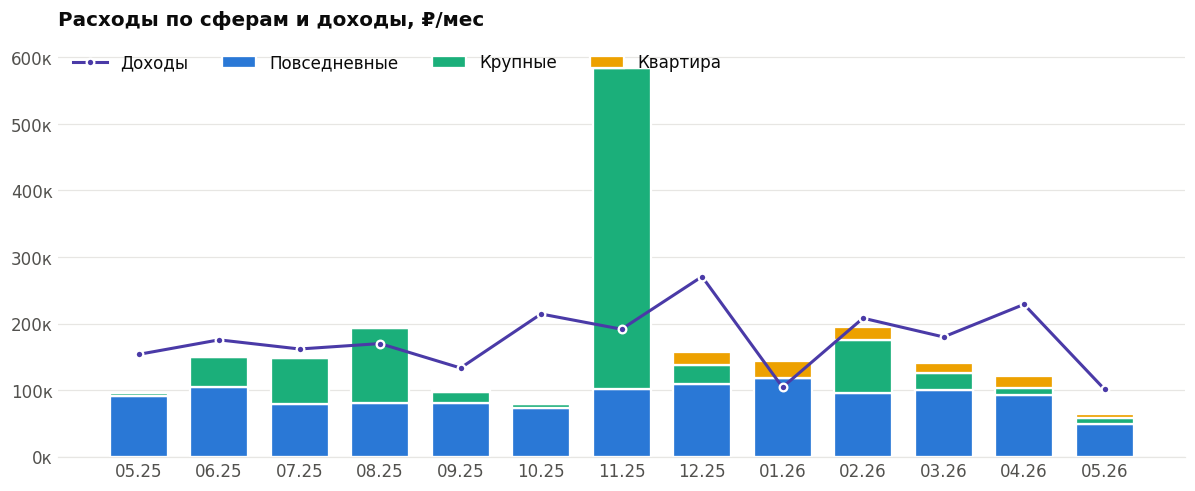

sphere_id,Повседневные,Квартира,Крупные,Расход,Доход,Дельта,Накопл.
2025-05,91к,0к,5к,96к,154к,58к,38%
2025-06,105к,4к,44к,153к,175к,22к,13%
2025-07,79к,0к,69к,148к,162к,14к,9%
2025-08,80к,2к,113к,195к,170к,-25к,-15%
2025-09,80к,3к,16к,99к,133к,34к,25%
2025-10,73к,0к,6к,79к,214к,136к,63%
2025-11,102к,3к,482к,587к,192к,-395к,-206%
2025-12,109к,19к,29к,157к,271к,113к,42%
2026-01,118к,26к,0к,144к,104к,-40к,-38%
2026-02,96к,19к,79к,195к,208к,13к,6%


In [4]:
from matplotlib.ticker import FuncFormatter

months = pd.period_range(df.month.min(), df.month.max(), freq="M")[-13:]
pv = (exp.pivot_table(index="month", columns="sphere_id", values="value",
                      aggfunc="sum")
         .reindex(months).fillna(0))
income_m = inc.groupby("month")["value"].sum().reindex(months).fillna(0)
x = range(len(months))
labels = [m.strftime("%m.%y") for m in months]

fig, ax = plt.subplots(figsize=(11, 4.6))
bottom = pd.Series(0.0, index=months)
cols = [s for s in sphere_order if s in pv.columns] + \
       [c for c in pv.columns if c not in sphere_order]
for sid in cols:
    ax.bar(x, pv[sid], 0.72, bottom=bottom,
           color=SPHERE_C.get(sid, NO_SPHERE_C),
           edgecolor="white", linewidth=1.5,
           label=sphere_names.get(sid, "Без сферы"))
    bottom += pv[sid]
ax.plot(x, income_m.values, color=INCOME_C, lw=2, marker="o", ms=5,
        markeredgecolor="white", markeredgewidth=1.5, label="Доходы")
ax.set_xticks(list(x), labels)
ax.yaxis.set_major_formatter(FuncFormatter(kilo))
ax.legend(frameon=False, ncol=6, loc="upper left", bbox_to_anchor=(0, 1.02))
style(ax, "Расходы по сферам и доходы, ₽/мес")
plt.tight_layout(); plt.show()

# Таблица (дублирует график числами — включая слабоконтрастные цвета)
tbl = pv.rename(columns=lambda c: sphere_names.get(c, "Без сферы")) / 1000
tbl["Расход"] = tbl.sum(axis=1)
tbl["Доход"] = income_m / 1000
tbl["Дельта"] = tbl["Доход"] - tbl["Расход"]
tbl["Накопл."] = (tbl["Дельта"] / tbl["Доход"]).where(tbl["Доход"] > 0)
(tbl.style.format("{:,.0f}к", subset=tbl.columns[:-1])
     .format("{:.0%}", subset=["Накопл."], na_rep="—"))

## Дельта месяца (доходы − расходы)

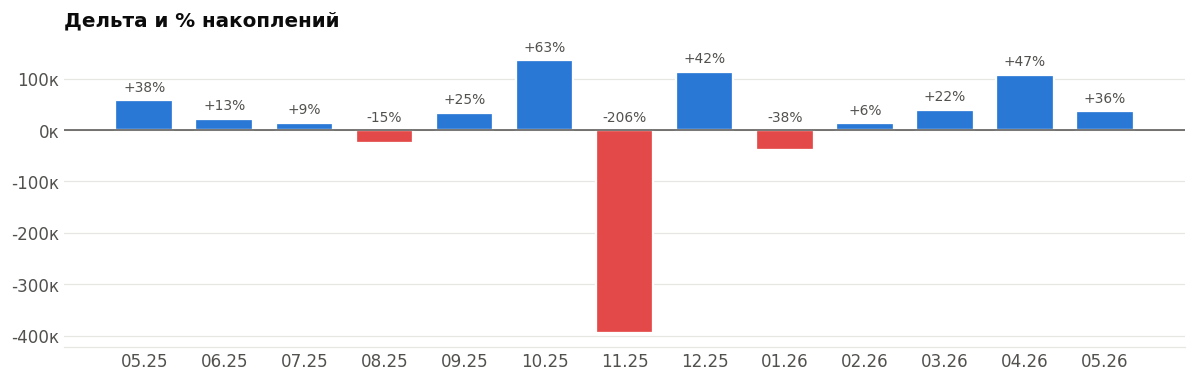

In [5]:
delta = income_m.values - pv.sum(axis=1).values
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(x, delta, 0.72, color=[POS_C if v >= 0 else NEG_C for v in delta],
       edgecolor="white", linewidth=1.5)
ax.axhline(0, color=MUTED, lw=1)
for i, v in enumerate(delta):
    inc_v = income_m.values[i]
    if inc_v > 0:
        # у отрицательных подпись над нулевой осью — не упирается в подписи месяцев
        anchor, off = ((i, v), (0, 6)) if v >= 0 else ((i, 0), (0, 6))
        ax.annotate(f"{v / inc_v:+.0%}", anchor, xytext=off,
                    textcoords="offset points", ha="center",
                    fontsize=9, color=MUTED)
ax.set_xticks(list(x), labels)
ax.yaxis.set_major_formatter(FuncFormatter(kilo))
style(ax, "Дельта и % накоплений")
plt.tight_layout(); plt.show()

## Повседневные: структура по категориям (весь период)

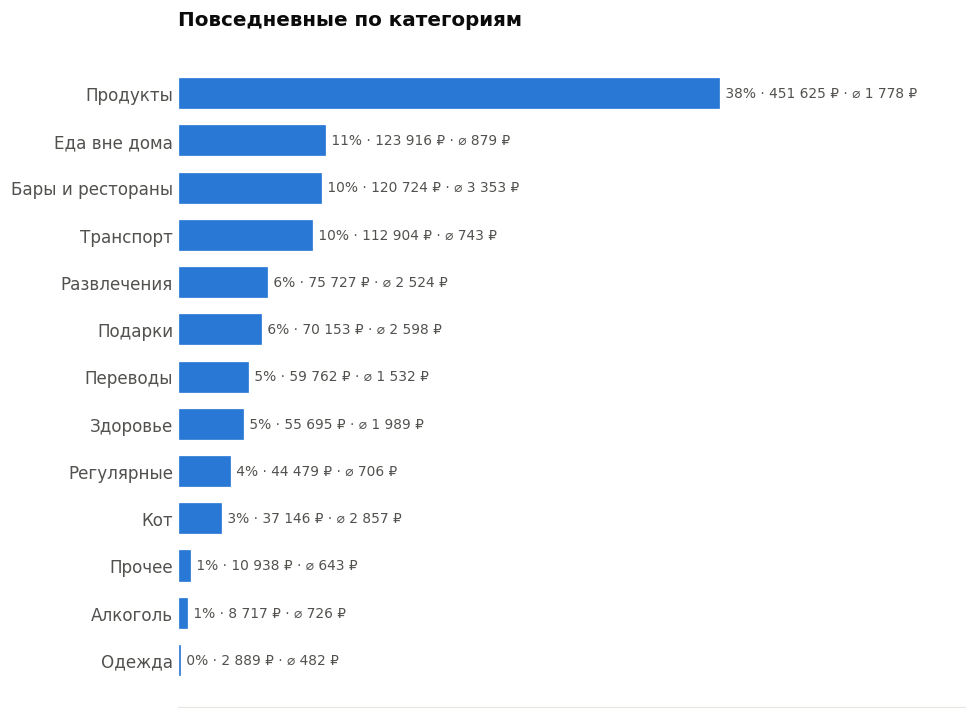

In [6]:
if len(daily):
    by_cat = daily.groupby("category")["value"].agg(["sum", "count", "mean"])
    by_cat = by_cat.sort_values("sum")
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(by_cat) + 1.2))
    bars = ax.barh(by_cat.index, by_cat["sum"], 0.7, color="#2a78d6",
                   edgecolor="white", linewidth=1.5)
    total = by_cat["sum"].sum()
    for b, (_, r) in zip(bars, by_cat.iterrows()):
        ax.annotate(f' {r["sum"] / total:.0%} · {rub(r["sum"])} · ⌀ {rub(r["mean"])}',
                    (b.get_width(), b.get_y() + b.get_height() / 2),
                    va="center", fontsize=9, color=MUTED)
    ax.set_xlim(0, by_cat["sum"].max() * 1.45)
    ax.grid(visible=False); ax.set_xticks([])
    style(ax, "Повседневные по категориям")
    plt.tight_layout(); plt.show()

## Повседневные: дни недели

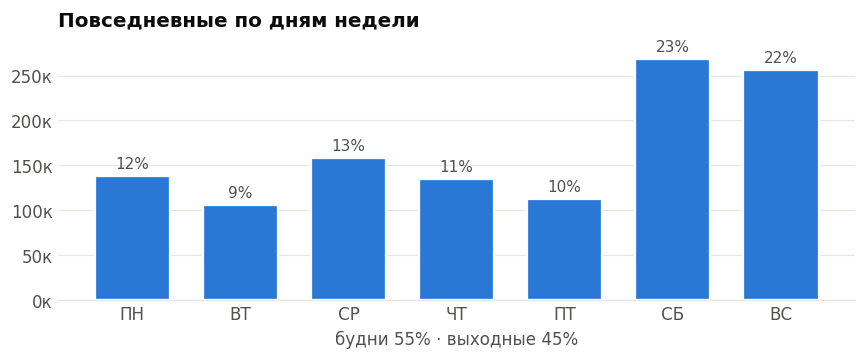

In [7]:
if len(daily):
    wd = daily.groupby(daily.date.dt.weekday)["value"].sum().reindex(range(7), fill_value=0)
    names = ["ПН", "ВТ", "СР", "ЧТ", "ПТ", "СБ", "ВС"]
    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.bar(names, wd.values, 0.7, color="#2a78d6",
           edgecolor="white", linewidth=1.5)
    for i, v in enumerate(wd.values):
        ax.annotate(f"{v / wd.sum():.0%}", (i, v), xytext=(0, 5),
                    textcoords="offset points", ha="center",
                    fontsize=10, color=MUTED)
    ax.yaxis.set_major_formatter(FuncFormatter(kilo))
    style(ax, "Повседневные по дням недели")
    wk, we = wd[:5].sum(), wd[5:].sum()
    ax.set_xlabel(f"будни {wk / wd.sum():.0%} · выходные {we / wd.sum():.0%}",
                  color=MUTED)
    plt.tight_layout(); plt.show()

## Теплокарта: категории повседневных по месяцам

Чем темнее — тем больше потрачено. Сразу видно сезонность и всплески.

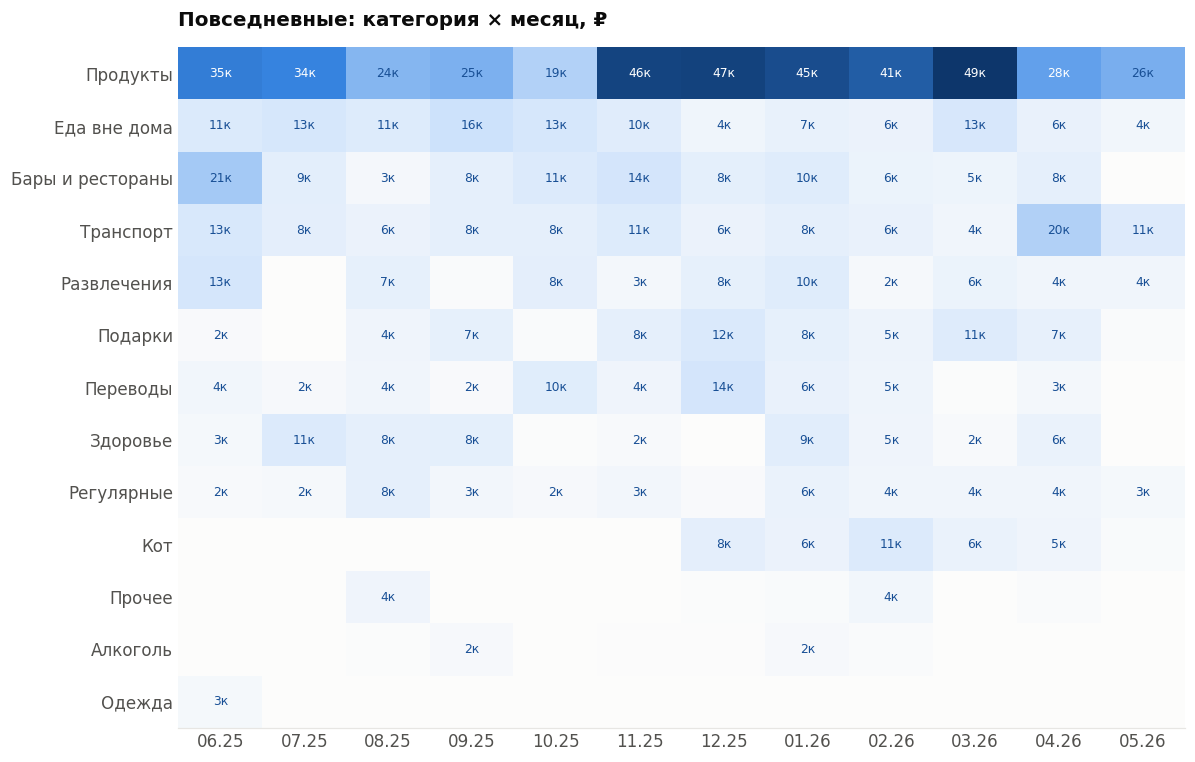

In [8]:
if len(daily):
    hm_months = months[-12:]
    top = daily.groupby("category")["value"].sum().sort_values(ascending=False)
    hm = (daily[daily.category.isin(top.index)]
          .pivot_table(index="category", columns="month", values="value",
                       aggfunc="sum")
          .reindex(index=top.index, columns=hm_months).fillna(0))
    fig, ax = plt.subplots(figsize=(11, 0.42 * len(hm) + 1.6))
    im = ax.imshow(hm.values, aspect="auto", cmap=BLUES)
    ax.set_xticks(range(len(hm_months)), [m.strftime("%m.%y") for m in hm_months])
    ax.set_yticks(range(len(hm)), hm.index)
    vmax = hm.values.max()
    for r in range(hm.shape[0]):
        for c in range(hm.shape[1]):
            v = hm.values[r, c]
            if v >= vmax * 0.03:
                ax.annotate(kilo(v), (c, r), ha="center", va="center", fontsize=8,
                            color="white" if v > vmax * 0.55 else "#184f95")
    ax.grid(visible=False); ax.tick_params(length=0)
    style(ax, "Повседневные: категория × месяц, ₽")
    plt.tight_layout(); plt.show()

## Динамика: повседневные за месяц и средний накопительным итогом

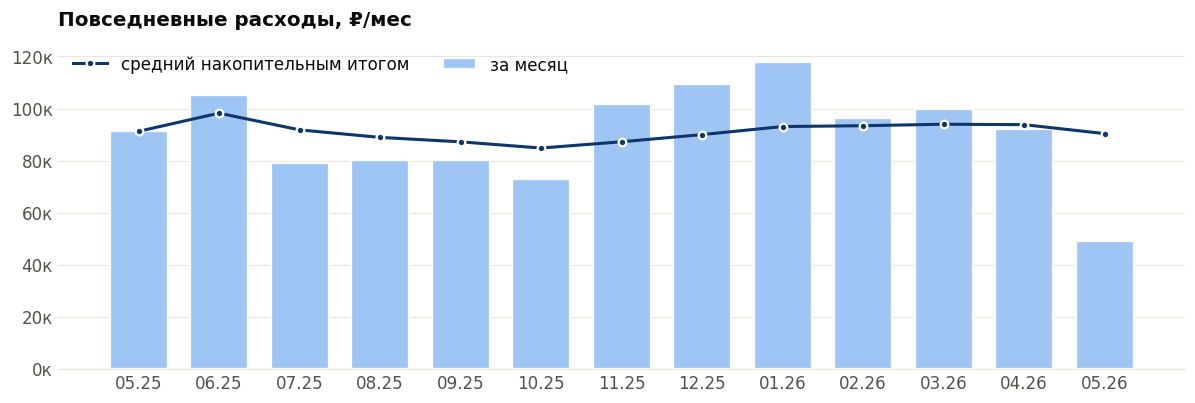

In [9]:
full = [m for m in months if m != pd.Timestamp.now().to_period("M")]
if len(full) > 1:
    dm = daily.groupby("month")["value"].sum().reindex(full).fillna(0)
    cum_avg = dm.expanding().mean()
    xs = range(len(full))
    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.bar(xs, dm.values, 0.72, color="#9ec5f4",
           edgecolor="white", linewidth=1.5, label="за месяц")
    ax.plot(xs, cum_avg.values, color="#0d366b", lw=2, marker="o", ms=5,
            markeredgecolor="white", markeredgewidth=1.5,
            label="средний накопительным итогом")
    ax.set_xticks(list(xs), [m.strftime("%m.%y") for m in full])
    ax.yaxis.set_major_formatter(FuncFormatter(kilo))
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.02), ncol=2)
    style(ax, "Повседневные расходы, ₽/мес")
    plt.tight_layout(); plt.show()

## Последние 90 дней: дневные траты, лимит и выбросы

медиана дня 2 174 ₽ · среднее 3 510 ₽


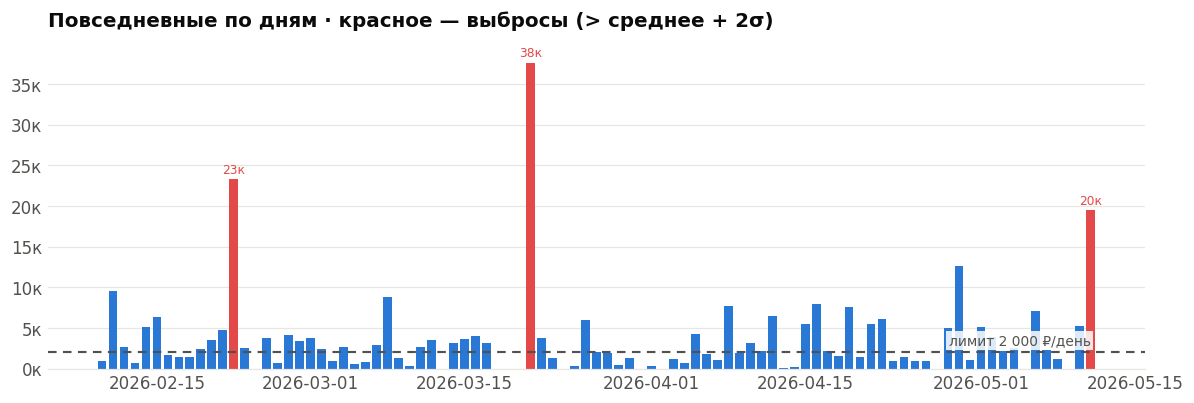

In [10]:
last = daily[daily.date >= daily.date.max() - pd.Timedelta(days=90)]
if len(last) > 5:
    by_day = last.groupby(last.date.dt.normalize())["value"].sum()
    idx = pd.date_range(by_day.index.min(), by_day.index.max(), freq="D")
    by_day = by_day.reindex(idx, fill_value=0)
    mean, sd = by_day.mean(), by_day.std(ddof=0)
    limit = sphere_meta.get("sphere_daily", {}).get("daily_limit")
    spike = by_day > mean + 2 * sd

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.bar(by_day.index, by_day.values, 0.8,
           color=["#e34948" if s else "#2a78d6" for s in spike])
    if limit:
        ax.axhline(limit, color=MUTED, lw=1.4, ls=(0, (4, 3)))
        ax.annotate(f"лимит {rub(limit)}/день", (by_day.index[-1], limit),
                    xytext=(0, 5), textcoords="offset points", ha="right",
                    fontsize=9, color=MUTED,
                    bbox=dict(fc="white", ec="none", alpha=0.85, pad=1.5))
    for d, v in by_day[spike].items():
        ax.annotate(kilo(v), (d, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, color="#e34948")
    ax.yaxis.set_major_formatter(FuncFormatter(kilo))
    style(ax, "Повседневные по дням · красное — выбросы (> среднее + 2σ)")
    print(f"медиана дня {rub(by_day.median())} · среднее {rub(mean)}")
    plt.tight_layout(); plt.show()

---
**Обновление данных:** iPhone → Настройки → Экспорт данных (JSON) → AirDrop на Mac →
замени путь в первой ячейке (или положи файл в корень проекта под именем
`trippocket-import.json`) → Run All.

Консольная версия того же отчёта: `python3 scripts/analyze.py <файл>`.